# Quantum State Prep - Part 2
**Writing the code** 

In this tutorial, we will continue developing a quantum state preparation algorithm using QDE tools. 
In part 1, we defined the high-level structure of the algorithm and designed a circuit diagram for it.
Now, we will implement this algorithm using Workbench and test our code.

## 1. Prepare a single-qubit state

Let's start with the base case of the recursion: preparing a single-qubit state $a_0|0\rangle + a_1|1\rangle$, parameterized with its amplitudes $a_0$ and $a_1$. This quantum program will be very simple, but it will introduce us to multiple Workbench tools:

* Defining the simulator to run the program
* Allocating qubits to use in your code
* Applying primitive gates to qubits
* Printing the program state at different points of its execution
* Printing a circuit implemented by the program

A Workbench program has to start by creating a `QPU` object - the representation of the quantum engine on which this program will run. Currently, Workbench supports a variety of simulators ("filters") that can be configured using arguments to the `QPU` constructor. By default, Workbench uses a full-state simulator that we can create by calling `QPU()` with one argument - the number of qubits we're planning to use in our program. 
This includes both the qubits our program allocates explicitly and any qubits allocated temporarily by library calls, gate decomposition, and so on. In our case, we'll only need one qubit:

```python
    qpu = QPU(num_qubits=1)
```

The next step is to allocate the qubit for our state preparation exercise. In Workbench, qubits are represented with the `Qubits` data type, and we can allocate them by calling the constructor. Notice that we have to specify not only the number of qubits we're allocating but also the QPU from which we're allocating them:

```python
    q = Qubits(1, "q", qpu)
```

Now, we're ready to start state preparation! Freshly allocated qubits start in the $|0\rangle$ state. We can convert our qubit to the state $a_0|0\rangle + a_1|1\rangle$ using an $Ry$ gate with the rotation angle $\theta = 2 \cdot \mathrm{atan2}(a_1, a_0)$. 

```python
    a0, a1 = 0.6, -0.8
    theta = 2 * atan2(a1, a0)
```

In Workbench, gates are methods of the `Qubits` class, so we can apply an $Ry$ gate to a qubit by calling the method `q.ry()`. The $Ry$ gate takes a numeric parameter, the rotation angle in degrees. Since the function `atan2` returns its result in radians, we need to convert the angle to degrees, for example, by multiplying it by `units.rad`.

```python
    q.ry(theta * units.rad)
```

At this point, our state preparation exercise should be done, but we don't have a way to see its results yet. We can take advantage of the fact that we're running this program on a simulator, and thus we can access its quantum state directly. `QPU` class has a method `print_state_vector` that prints the state of the QPU, in this case the state of the one qubit we have allocated and prepared.

```python
    qpu.print_state_vector()
```

Putting these steps together gives us the following script.

|q>
|0>    0.600000+0.000000j
|1>    -0.800000+0.000000j


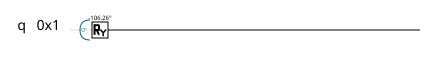

In [ ]:
from math import atan2
from psiqdk.workbench import QPU, Qubits, units

# Define a QPU instance to run the program on
qpu = QPU(num_qubits=1)

# Allocate a qubit
q = Qubits(1, "q", qpu)

# The amplitudes of the state we want to prepare
a0, a1 = 0.6, -0.8
# Calculate the required rotation angle
theta = 2 * atan2(a1, a0)

# Apply Ry gate with that angle to the qubit
q.ry(theta * units.rad)

# Print the quantum state of the QPU
qpu.print_state_vector()

# Print the circuit
qpu.nop(repeat=16)
qpu.draw()

## 2. Test state preparation code

In the previous code snippet, we confirmed our quantum state was prepared correctly by printing the quantum state of the program and comparing it with the input amplitudes by hand. 
Before we continue building up our state preparation code to handle two-qubit and then multi-qubit cases, let's add tests to it to automate this check.
This will allow us to learn more Workbench tools:

* Structuring the code to make it easy to reuse and test
* Fetching the quantum state of a program to use it programmatically

To start with, let's refactor the code to separate QPU configuration and qubit allocation from the actual state preparation logic. We'll create a function that will take two arguments: the qubit on which we need to prepare the state and the array of amplitudes that describes that state. This function will focus on just applying the required gates to the qubit:

```python
    def prep_one_qubit(q: Qubits, amps: list[float]):
        theta = 2 * atan2(amps[1], amps[0])
        q.ry(theta * units.radians)
```

After this, we can call this function whenever we want to prepare a qubit:

```python
    q = Qubits(1, "q", qpu)
    amps = [0.6, -0.8]
    prep_one_qubit(q, amps)
```

Now, to write tests that validate the quantum state of the program automatically, we need a way to extract that state and make it available to the rest of the code. In Workbench, the `QPU` class has a method `pull_state` that returns the state vector of the program as an array of complex amplitudes:

```python
    prepared_amps = qpu.pull_state()
```

After this, we can work with the state vector using regular Python tools, for example, check that it matches the vector of amplitudes passed to the state preparation function using the method `pytest.approx`:

```python
    assert prepared_amps == approx(amps)
```

The final step is coming up with a set of test cases to use and running through them in a loop, testing the state preparation logic one state at a time.

Note that we'll need to reset the QPU on every iteration to make sure each test starts with a clean slate. We can do that using the `reset` method of the QPU object; this method takes one argument, the number of qubits the next run of the program will use. If we use `reset`, we don't need to pass the number of qubits to the QPU object constructor:

```python
    qpu = QPU()
    qpu.reset(1)
```

In [2]:
from math import atan2, sqrt
from pytest import approx
from psiqdk.workbench import QPU, Qubits, units

def prep_one_qubit(q: Qubits, amps: list[float]):
    'Prepare one-qubit state with the given amplitudes'
    theta = 2 * atan2(amps[1], amps[0])
    q.ry(theta * units.rad)

def test_prep_one_qubit():
    qpu = QPU()

    test_amps = [[1, 0], [0, 1], [-1, 0], [0, -1], [0.6, 0.8], [0.8, -0.6], [-1/sqrt(2), 1/sqrt(2)], [-2/sqrt(5), -1/sqrt(5)]]
    for amps in test_amps:
        # Reset the QPU on each test case
        qpu.reset(1)
        q = Qubits(1, "q", qpu)

        # Call the function we're testing
        prep_one_qubit(q, amps)

        # Get the quantum state of the QPU as a vector
        prepared_amps = qpu.pull_state()

        # Compare the amplitudes of the state that was prepared with the expected ones
        assert prepared_amps == approx(amps)
    
    print("One-qubit state preparation tests passed")

test_prep_one_qubit()

One-qubit state preparation tests passed


## 3. Prepare a two-qubit state

Now, let's modify our code to prepare two-qubit states. This will let us learn how to use simple controlled gates in Workbench.

Workbench uses little-endian to map bit strings to integers in basis states representations: basis state $|10\rangle$ will be written as $|1\rangle$, and $|01\rangle$ - as $|2\rangle$. This means that Workbench representation of a two-qubit state with amplitudes mapped to basis states looks as follows:

$$a_0|0\rangle + a_1|1\rangle + a_2|2\rangle + a_3|3\rangle = a_0|00\rangle + a_1|10\rangle + a_2|01\rangle + a_3|11\rangle$$

We can prepare this state using the following sequence of steps:

1. Prepare the first (least significant) qubit in the state $\sqrt{a_0^2 + a_2^2}|0\rangle + \sqrt{a_1^2 + a_3^2}|1\rangle$. Same as in our single-qubit state preparation code, we can do this using an $Ry$ gate with rotation angle $\theta = 2 \cdot \mathrm{atan2} \left( \sqrt{a_1^2 + a_3^2}, \sqrt{a_0^2 + a_2^2} \right)$.

2. Use controlled-on-zero $Ry$ gate to change the first term of the two-qubit state from $\sqrt{a_0^2 + a_2^2}|0\rangle \otimes |0\rangle$ to $a_0|00\rangle + a_2|01\rangle$. The rotation angle for this gate is $\theta_0 = 2 \cdot \mathrm{atan2} \left( \frac{a_2}{\sqrt{a_0^2 + a_2^2}}, \frac{a_0}{\sqrt{a_0^2 + a_2^2}} \right)$. Since $\mathrm{atan2}$ doesn't require its arguments to be normalized, we can just use $\theta_0 = 2 \cdot \mathrm{atan2}(a_2, a_0)$ instead.

3. Use controlled-on-one $Ry$ gate to change the second term of the two-qubit state from $\sqrt{a_1^2 + a_3^2}|1\rangle \otimes |0\rangle$ to $a_1|10\rangle + a_3|11\rangle$. Similarly, the rotation angle for this gate is $\theta_1 = 2 \cdot \mathrm{atan2}(a_3, a_1)$.

To prepare a two-qubit state, we'll modify our single-qubit state preparation function to now act on two qubits. (We will return to the single-qubit scenario as the base case of the recursion for preparing a multi-qubit state.)

```python
    def prep_two_qubit(qs: Qubits, amps: list[float]):
        # ...
```

In Workbench, calling a gate method of a `Qubits` object applies this gate to *each* of the qubits of that object, using them as gate targets. To apply one $Ry$ gate, controlled or not, we need to get a `Qubits` object that describes one qubit and call the `ry` method of that object. We can use slicing to get a subset of qubits in a `Qubits` object. For example, if we allocated qubits using `qs = Qubits(2, ...)`, then `qs[0]` and `qs[1]` give us the first and the second qubits of the input `Qubits`, respectively. We can implement the first step by calculating the angle `theta` and then calling `ry` method as follows:

```python
    qs[0].ry(theta * units.rad)
```

The next two steps use controlled $Ry$ gates, with the second qubit `qs[1]` as the target and the first qubit `qs[0]` as the control. We will need to use the `ry` method of the object `qs[1]` to select the target of the gate and specify the control qubit via the method arguments. The `cond` argument provides the list of all qubits used as controls for this gate. Thus the third step of the state preparation algorithm, controlled-on-one $Ry$ gate, can be expressed as follows:

```python
    qs[1].ry(theta1 * units.rad, cond=qs[0])
```

The second step of the state preparation algorithm requires a controlled-on-zero $Ry$ gate. We can apply that similarly to how we applied a controlled-on-one gate, with one change: the condition on which the gate is applied will now be `qs[0] == 0` rather than just `qs[0]`. This shorthand is syntactic sugar for evaluating the equality condition in-place and using the result as gate control before uncomputing this condition.

```python
    qs[1].ry(theta0 * units.rad, cond=qs[0] == 0)
```

Finally, we update the tests to cover the two-qubit case. To do this, we need to update the qubit count in the `qpu.reset` call and in the qubit allocation afteward, and to use lists of four amplitudes instead of two.

Two-qubit state preparation tests passed


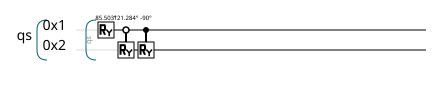

In [3]:
from math import atan2, sqrt
from pytest import approx
from psiqdk.workbench import QPU, Qubits, units

def prep_two_qubit(qs: Qubits, amps: list[float]):
    'Prepare two-qubit state with the given amplitudes'

    # Prepare the least significant qubit (LSB)
    b0 = sqrt(amps[0] ** 2 + amps[2] ** 2)
    b1 = sqrt(amps[1] ** 2 + amps[3] ** 2)
    theta = 2 * atan2(b1, b0)
    qs[0].ry(theta * units.rad)

    # Prepare the most significant bit, controlled on LSB=0
    theta0 = 2 * atan2(amps[2], amps[0])
    qs[1].ry(theta0 * units.rad, cond=qs[0] == 0)

    # Prepare the most significant bit, controlled on LSB=1
    theta1 = 2 * atan2(amps[3], amps[1])
    qs[1].ry(theta1 * units.rad, cond=qs[0])


def test_prep_two_qubit():
    qpu = QPU()

    test_amps = [[1., 0., 0., 0.], [-0.5, 0.5, 0.5, -0.5], [0.36, 0.48, 0.64, -0.48], [1/sqrt(2), 0, 0, 1/sqrt(2)], [0, 1/sqrt(3), -1/sqrt(3), 1/sqrt(3)]]
    for amps in test_amps:
        qpu.reset(2)
        qs = Qubits(2, "qs", qpu)

        # Call the function we're testing
        prep_two_qubit(qs, amps)

        # Get the quantum state of the QPU as a vector
        prepared_amps = qpu.pull_state()

        # Compare the amplitudes of the state that was prepared with the expected ones
        assert prepared_amps == approx(amps)
    
    print("Two-qubit state preparation tests passed")

test_prep_two_qubit()

# Print the circuit for one test case
qpu = QPU(num_qubits=2)
qs = Qubits(2, "qs", qpu)
prep_two_qubit(qs, [0.36, 0.48, 0.64, -0.48])
qpu.nop(repeat=14)
qpu.draw()

## 4. Prepare a multi-qubit state

Finally, let's generalize our state preparation function to cover the multi-qubit case. This will add controlled gates implementation to our Workbench toolkit.

The multi-qubit state with $n$ qubits we want to prepare looks as follows:

$$a_0 |0\rangle + a_1 |1\rangle + ... + a_{2^n - 1} |2^n - 1\rangle$$

Let's recall that Workbench uses little-endian to map bit strings to integers when working with basis states. This means that we can separate the first qubit that stores the least significant bit from the remaining $n-1$ qubits that store the most significant bits and rewrite the state as follows:

$$a_0 |0\rangle |0\rangle_{n-1} + a_1 |1\rangle |0\rangle_{n-1} + a_2 |0\rangle |1\rangle_{n-1} + a_3 |1\rangle |1\rangle_{n-1} + ...$$
$$+ a_{2^n - 2} |0\rangle |2^{n-1} - 1\rangle_{n-1} + a_{2^n - 1} |1\rangle |2^{n-1} - 1\rangle_{n-1}$$

(Here, the ket symbol with subscript $n-1$ denotes an $n-1$-qubit state.)

Now, we can reorder the terms to group the basis states with the same least significant bit together:

$$|0\rangle \otimes \left( a_0 |0\rangle_{n-1} + a_2 |1\rangle_{n-1} + ... + a_{2^n - 2} |2^{n-1} - 1\rangle_{n-1} \right)$$
$$+ |1\rangle \otimes \left( a_1 |0\rangle_{n-1} + a_3 |1\rangle_{n-1} + ... + a_{2^n - 1} |2^{n-1} - 1\rangle_{n-1} \right)$$

This expression points us to the recursive algorithm for the general case:

1. Prepare the first (least significant qubit) in the state 
$\sqrt{a_0^2 + a_2^2 + ... + a_{2^n-2}^2} |0\rangle + \sqrt{a_1^2 + a_2^2 + ... + a_{2^n-1}^2} |1\rangle$.

2. Use controlled-on-zero state preparation routine to change the first term of the $n$-qubit state:  
$$\sqrt{a_0^2 + a_2^2 + ... + a_{2^n-2}^2} |0\rangle \otimes |0\rangle_{n-1} \rightarrow $$
$$|0\rangle \otimes \left( a_0 |0\rangle_{n-1} + a_2 |1\rangle_{n-1} + ... + a_{2^n - 2} |2^{n-1} - 1\rangle_{n-1} \right)$$

4. Use controlled-on-one state preparation routine to change the second term of the $n$-qubit state:  
$$\sqrt{a_1^2 + a_2^2 + ... + a_{2^n-1}^2} |1\rangle \otimes |0\rangle_{n-1} \rightarrow$$
$$|1\rangle \otimes \left( a_1 |0\rangle_{n-1} + a_3 |1\rangle_{n-1} + ... + a_{2^n - 1} |2^{n-1} - 1\rangle_{n-1} \right)$$

To implement this algorithm, we'll modify our two-qubit state preparation routine to handle an arbitrary number of qubits and to support its controlled variant. To implement a controlled variant of a function in Workbench, you need to add an extra optional argument to it that describes the qubit(s) used as the control. Workbench supports several ways of describing qubit arrays (a list of their indices or a bitmask that combines them into on integer), so let's use a type annotation that matches them:

```python
    def prep_multiqubit(qs: Qubits, amps: list[float], cond: int | list[int] | None = None):
        # ...
```

The first thing this function needs to do is distinguish between the base case of recursion that can be handled immediately (a single-qubit state) and the other cases that require at least one recursive step (states with two or more qubits). We can do this using the field `num_qubits` of the `Qubits` class that gives us the number of qubits in the register.

```python
    if qs.num_qubits == 1:
        # Single-qubit case
    else:
        # Multi-qubit case
```

> You'll notice that we make a lot of assumptions here: we assume that the given qubit register is not empty, that the length of the amplitudes list matches the number of amplitudes required to describe the register of the given length, that the amplitudes list is not all zeroes... We're omitting the checks for these scenarios to keep this tutorial short. When developing a real code library, you should definitely include them! 

The code for the single-qubit case is similar to the one we wrote at the beginning of this tutorial, with one difference. We need to be able to call the controlled variant of this code, so each quantum operation in it needs to handle the control register appropriately. Here, we'll need to add the `cond` argument to the `ry` method, same as we did in the two-qubit case, to call the controlled variant of the gate if the control register is not empty.

```python
    qs.ry(theta * units.rad, cond=cond)
```

The structure of the code for the multi-qubit case is similar to that of the two-qubit code, but now instead of calling specific rotation gates we call state preparation routines with fewer qubits. Notice how we handle control register: when we call state preparation for the least significant qubit, which is not controlled as part of the algorithm itself, we just pass the `cond` argument to it without changes:  

```python
    prep_multiqubit(qs[0], [b0, b1], cond)
```

But when we call controlled variants of state preparation for the most significant qubits, we combine the `cond` argument and the condition involving the least significant qubit used as control by the algorithm to get a control register with more qubits:

```python
    prep_multiqubit(qs[1:], even_amps, cond | (qs[0] == 0))
    prep_multiqubit(qs[1:], odd_amps,  cond | qs[0])
```

Multi-qubit state preparation tests passed


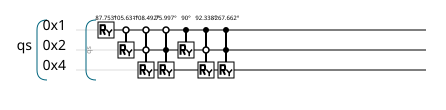

In [4]:
from math import atan2, sqrt
from pytest import approx
from random import uniform
from psiqdk.workbench import QPU, Qubits, units

def prep_multiqubit(qs: Qubits, amps: list[float], cond: int | list[int] | None = None):
    'Prepare multi-qubit state with the given amplitudes'

    if qs.num_qubits == 1:
        theta = 2 * atan2(amps[1], amps[0])
        qs.ry(theta * units.rad, cond=cond)
    else:
        # Prepare the least significant qubit (LSB)
        even_amps = amps[0::2]
        odd_amps = amps[1::2]
        b0 = sqrt(sum(a * a for a in even_amps))
        b1 = sqrt(sum(a * a for a in odd_amps))

        # Make sure to pass the control register as an argument
        # to allow the entire routine to be controlled.
        prep_multiqubit(qs[0], [b0, b1], cond)

        # Prepare the most significant n-1 bits, controlled on LSB=0
        prep_multiqubit(qs[1:], even_amps, cond | (qs[0] == 0))

        # Prepare the most significant n-1 bits, controlled on LSB=1
        prep_multiqubit(qs[1:], odd_amps,  cond | qs[0])


def test_prep_multiqubit():
    qpu = QPU()

    for n in range(1, 6):
        for _ in range(10):
            # Generate a random quantum state with normalized amplitude
            amps_raw = [uniform(-1.0, 1.0) for _ in range(2 ** n)]
            norm = sqrt(sum(a * a for a in amps_raw))
            amps = [a / norm for a in amps_raw]

            qpu.reset(n)
            qs = Qubits(n, "qs", qpu)

            prep_multiqubit(qs, amps)

            prepared_amps = qpu.pull_state()
            assert prepared_amps == approx(amps)
    
    print("Multi-qubit state preparation tests passed")

test_prep_multiqubit()

# Print the circuit for three-qubit test case
qpu = QPU()
qpu.reset(3)
qs = Qubits(3, "qs", qpu)
prep_multiqubit(qs, [0.36, 0.48, 0.64, -0.48, -0.5, 0.5, 0.5, -0.5])
qpu.nop(repeat=10)
qpu.draw()

## Conclusion

In this tutorial, we implemented the recursive state preparation algorithm and tested our program using Workbench.

In the [final part of this tutorial](./stateprep_3_qre_analysis.ipynb), we will analyze the performance of our program using Workbench QRE tools.